In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries loaded!")

Libraries loaded!


In [9]:
PATH = "E:/portfoilo/olist-ecommerce-analysis/data/raw/"

orders    = pd.read_csv(PATH + 'olist_orders_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')
items     = pd.read_csv(PATH + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(PATH + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(PATH + 'olist_order_reviews_dataset.csv')
products  = pd.read_csv(PATH + 'olist_products_dataset.csv')
sellers   = pd.read_csv(PATH + 'olist_sellers_dataset.csv')
category  = pd.read_csv(PATH + 'product_category_name_translation.csv')

print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Items: {items.shape}")
print(f"Products: {products.shape}")

Orders: (99441, 8)
Customers: (99441, 5)
Items: (112650, 7)
Products: (32951, 9)


In [ ]:
# Data Overview
print("=== ORDERS ===")
print(orders.info())
print("\n", orders.head(3))

=== ORDERS ===
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
None

                            order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c

In [11]:
# check missing values
dfs = {
    'orders': orders, 'customers': customers,
    'items': items, 'products': products,
    'payments': payments, 'reviews': reviews,
    'sellers': sellers
}

for name, df in dfs.items():
    missing = df.isnull().sum().sum()
    print(f"{name:12s} → {missing} missing values")

orders       → 4908 missing values
customers    → 0 missing values
items        → 0 missing values
products     → 2448 missing values
payments     → 0 missing values
reviews      → 145903 missing values
sellers      → 0 missing values


In [12]:
# Data cleaning
# แปลง date columns
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# คำนวณ delivery days และ is_late
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

orders['is_late'] = (
    orders['order_delivered_customer_date'] >
    orders['order_estimated_delivery_date']
).astype(int)

# กรองเฉพาะ delivered orders
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

print(f"Delivered orders: {orders_clean.shape[0]:,}")
print(f"Late deliveries: {orders_clean['is_late'].sum():,} ({orders_clean['is_late'].mean()*100:.1f}%)")

Delivered orders: 96,478
Late deliveries: 7,826 (8.1%)


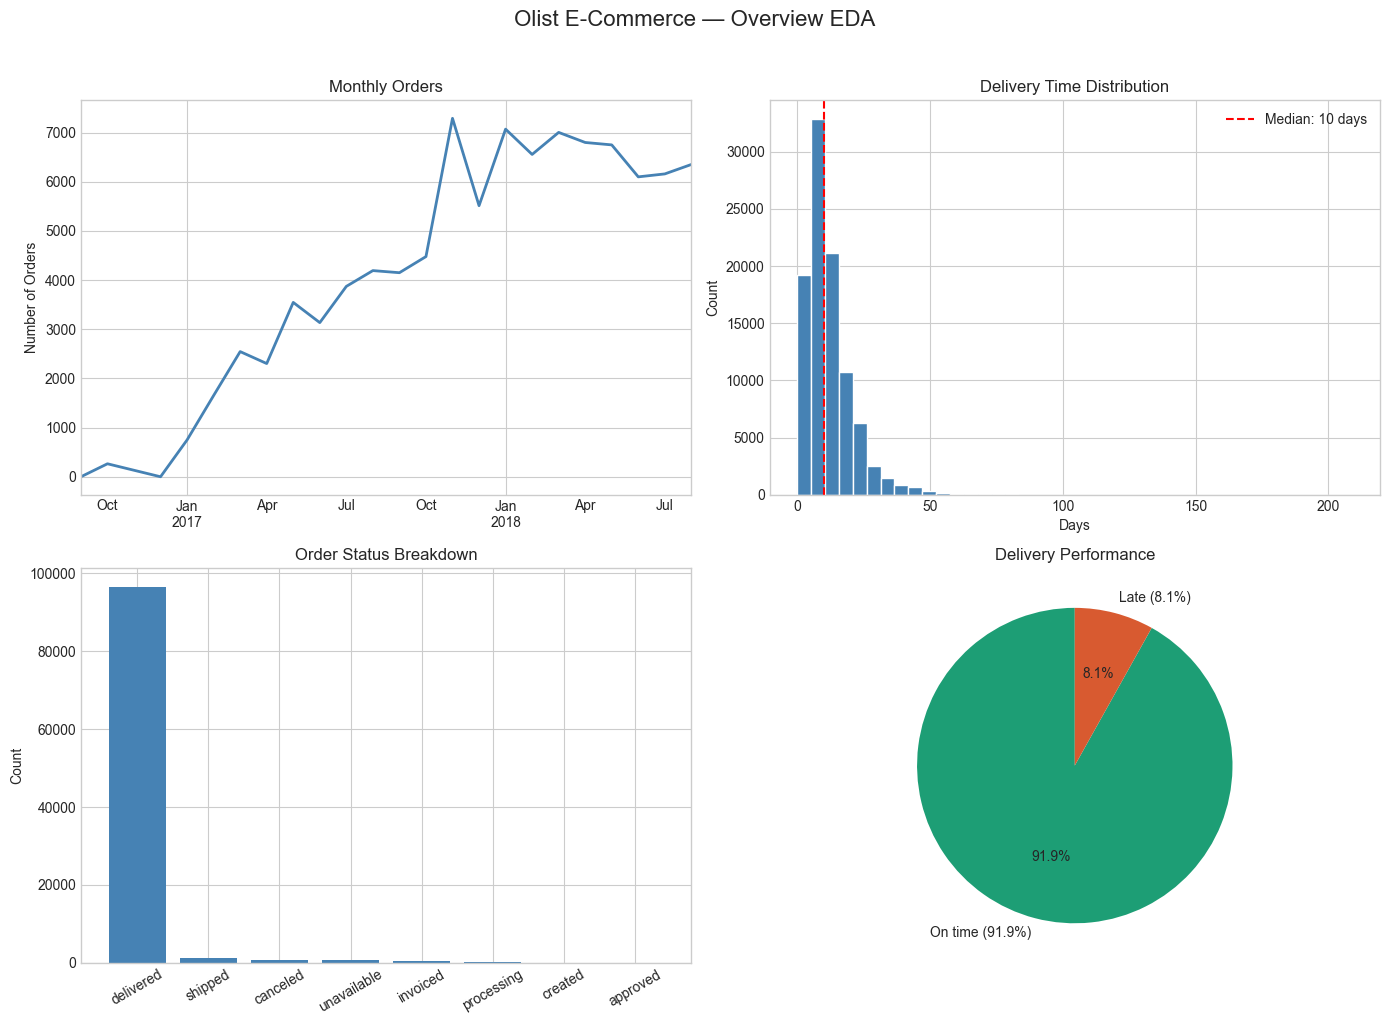

Saved to reports/figures/01_overview.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Olist E-Commerce — Overview EDA', fontsize=16, y=1.02)

# 1. Monthly orders trend
orders_clean['month'] = orders_clean['order_purchase_timestamp'].dt.to_period('M')
monthly = orders_clean.groupby('month').size()
monthly.plot(ax=axes[0,0], color='steelblue', linewidth=2)
axes[0,0].set_title('Monthly Orders')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Number of Orders')

# 2. Delivery time distribution
axes[0,1].hist(orders_clean['delivery_days'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0,1].set_title('Delivery Time Distribution')
axes[0,1].set_xlabel('Days')
axes[0,1].set_ylabel('Count')
axes[0,1].axvline(orders_clean['delivery_days'].median(), color='red', linestyle='--', label=f"Median: {orders_clean['delivery_days'].median():.0f} days")
axes[0,1].legend()

# 3. Order status breakdown
status_counts = orders['order_status'].value_counts()
axes[1,0].bar(status_counts.index, status_counts.values, color='steelblue')
axes[1,0].set_title('Order Status Breakdown')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_ylabel('Count')

# 4. Late vs on-time
late_counts = orders_clean['is_late'].value_counts()
axes[1,1].pie(late_counts, labels=['On time (91.9%)', 'Late (8.1%)'],
              autopct='%1.1f%%', colors=['#1D9E75', '#D85A30'],
              startangle=90)
axes[1,1].set_title('Delivery Performance')

plt.tight_layout()
plt.savefig('E:/portfoilo/olist-ecommerce-analysis/reports/figures/01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to reports/figures/01_overview.png")

## Key Insights

- **96,478 delivered orders** จากทั้งหมด 99,441 orders (97.0%)
- **8.1% ส่งช้ากว่ากำหนด** — คิดเป็น 7,826 orders ที่ลูกค้าได้รับสินค้าล่าช้า
- **reviews ขาดหาย 145,903 rows** — ส่วนใหญ่เป็น review text ที่ลูกค้าไม่ได้เขียน ไม่ใช่ข้อมูลสำคัญหาย
- **products ขาดหาย 2,448 rows** — น่าจะเป็น category ที่ยังไม่มีคำแปลภาษาอังกฤษ